In [1]:
import os
import numpy as np
from PIL import Image as PILImage

# --- 配置 ---
IMG_DIR = '/home/xilinx/jupyter_notebooks/duxu/pynq_vqvae/imgs'
SAVE_DIR = '/home/xilinx/jupyter_notebooks/duxu/pynq_vqvae/imgs_preprocessed'
TARGET_SIZE = (700, 500)  # (W, H)
# 这里的 scale 需要和你的 DPU Encoder 输入 scale 一致 (2^-6 = 0.015625)
ENC_IN_SCALE = 0.015625 

if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

files = sorted([f for f in os.listdir(IMG_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

print(f"开始预处理 {len(files)} 张图片...")

for f in files:
    # 1. 加载与缩放 (与训练/原始逻辑保持一致)
    img_pil = PILImage.open(os.path.join(IMG_DIR, f)).convert('RGB')
    img_small = img_pil.resize(TARGET_SIZE, PILImage.BILINEAR)
    
    # 2. 归一化到 [-1, 1]
    img_arr = np.asarray(img_small, dtype=np.float32)
    input_fp32 = (img_arr / 255.0 - 0.5) / 0.5
    
    # 3. 量化为 int8 (DPU 直接输入格式)
    input_int8 = np.clip(np.round(input_fp32 / ENC_IN_SCALE), -128, 127).astype(np.int8)
    
    # 4. 保存为 numpy 格式，读取速度极快
    save_path = os.path.join(SAVE_DIR, f + '.npy')
    np.save(save_path, input_int8)

print(f"✅ 处理完成，数据保存在: {SAVE_DIR}")

开始预处理 10 张图片...
✅ 处理完成，数据保存在: /home/xilinx/jupyter_notebooks/duxu/pynq_vqvae/imgs_preprocessed


🔍 找到 10 张预处理图片，正在准备预览...


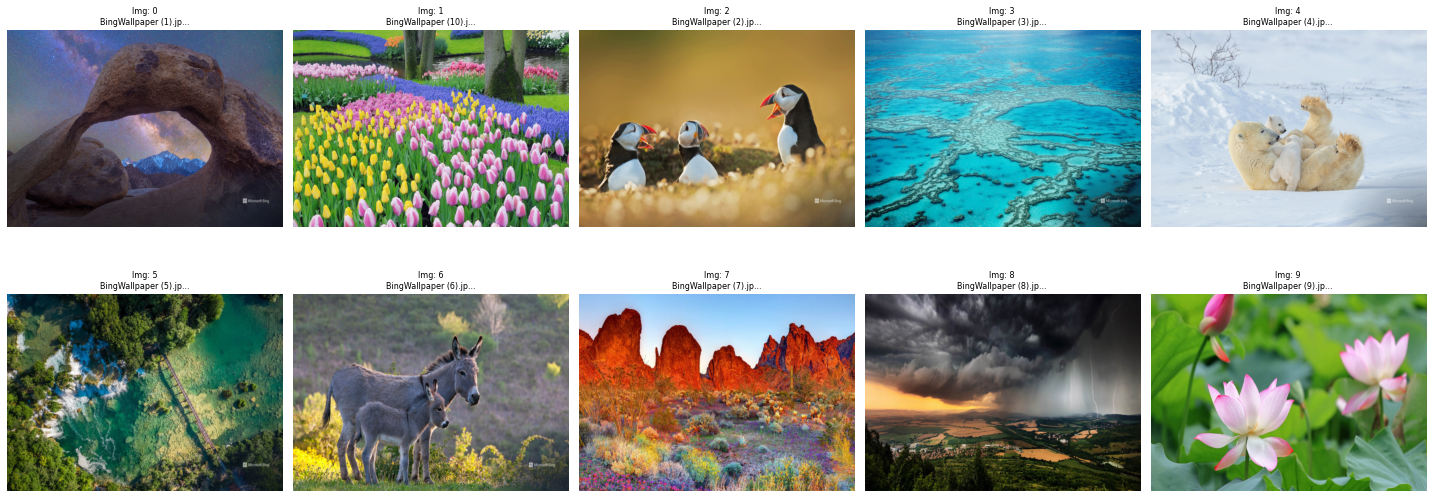

✅ 所有图片展示完毕。请检查图片是否存在偏色、过暗或噪点。


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import math

# --- 配置 ---
SAVE_DIR = '/home/xilinx/jupyter_notebooks/duxu/pynq_vqvae/imgs_preprocessed'
ENC_IN_SCALE = 0.015625  # 必须与预处理时的 scale 一致 (2^-6)

# 1. 获取所有 npy 文件
npy_files = sorted([f for f in os.listdir(SAVE_DIR) if f.endswith('.npy')])
num_imgs = len(npy_files)

if num_imgs == 0:
    print(f"❌ 错误：在 {SAVE_DIR} 文件夹下未找到 .npy 文件。")
else:
    print(f"🔍 找到 {num_imgs} 张预处理图片，正在准备预览...")

    # 2. 计算展示网格的行数和列数 (假设每行显示 5 张)
    cols = 5
    rows = math.ceil(num_imgs / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
    axes = axes.flatten() # 展平方便循环

    for i in range(len(axes)):
        if i < num_imgs:
            # 加载 int8 数据
            data_int8 = np.load(os.path.join(SAVE_DIR, npy_files[i]))
            
            # 还原量化与归一化
            # int8 -> fp32 -> 原图范围 [0, 1]
            data_fp32 = data_int8.astype(np.float32) * ENC_IN_SCALE
            img_rgb = (data_fp32 * 0.5 + 0.5).clip(0, 1)
            
            # 显示图片
            axes[i].imshow(img_rgb)
            axes[i].set_title(f"Img: {i}\n{npy_files[i][:20]}...", fontsize=8)
            axes[i].axis('off')
        else:
            # 隐藏多余的子图格
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()
    print("✅ 所有图片展示完毕。请检查图片是否存在偏色、过暗或噪点。")